# 02 — Analysis

Loads experiment data from Google Drive and runs all analyses.

**Run `01_run_experiment.ipynb` first** to generate `data_MODEL_DATE.csv` files.

## 1. Setup

In [1]:
# Clone repo (if not already done in this session)
!git clone https://github.com/auertobias/authority-bias-llm.git 2>/dev/null || echo "Already cloned"
%cd authority-bias-llm

from google.colab import drive
drive.mount('/content/drive')

/content/authority-bias-llm
Mounted at /content/drive


In [2]:
!pip install -q statsmodels

import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf

sys.path.insert(0, '.')
from src.config import DATA_PATH, RESULTS_PATH

os.makedirs(RESULTS_PATH, exist_ok=True)
print(f"Reading data from: {DATA_PATH}")
print(f"Saving results to: {RESULTS_PATH}")

Reading data from: /content/drive/MyDrive/PhD/2PhD 1Paper/data/
Saving results to: /content/drive/MyDrive/PhD/2PhD 1Paper/results/


## 2. Load Data
Automatically finds and combines all `data_MODEL_DATE.csv` files.

In [3]:
data_files = sorted(glob.glob(DATA_PATH + "data_*.csv"))

if not data_files:
    raise FileNotFoundError(
        f"No data files found in {DATA_PATH}\n"
        "Run 01_run_experiment.ipynb first."
    )

print(f"Found {len(data_files)} file(s):")
dfs = []
for f in data_files:
    tmp = pd.read_csv(f)
    dfs.append(tmp)
    print(f"  {os.path.basename(f):40s} {len(tmp)} rows")

df_raw = pd.concat(dfs, ignore_index=True)
df = df_raw.dropna(subset=['rating']).copy()
df['rating'] = df['rating'].astype(int)

print(f"\nCombined: {len(df_raw)} total, {len(df)} valid ratings ({100*len(df)/len(df_raw):.1f}%)")
print(f"Models:   {df['model'].unique().tolist()}")

Found 1 file(s):
  data_gpt_20260311.csv                    1776 rows

Combined: 1776 total, 1776 valid ratings (100.0%)
Models:   ['gpt']


## 3. Quality Checks

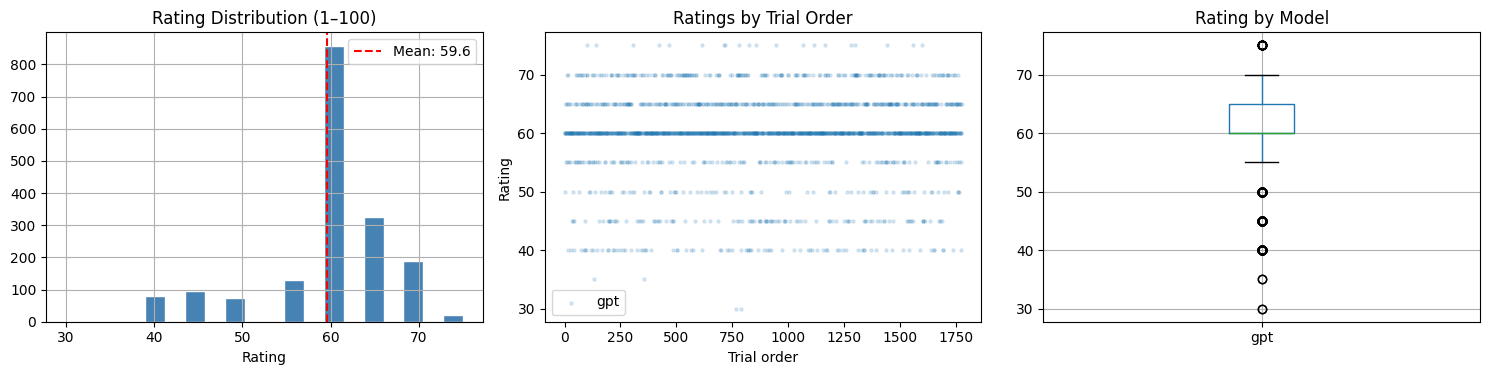

Sequential correlation by model:
  gpt        r=0.042, p=0.076 ✓


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Rating distribution
df['rating'].hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution (1–100)')
axes[0].set_xlabel('Rating')
axes[0].axvline(df['rating'].mean(), color='red', ls='--',
                label=f"Mean: {df['rating'].mean():.1f}")
axes[0].legend()

# Sequential independence
for name, mdf in df.groupby('model'):
    mdf = mdf.sort_index().reset_index(drop=True)
    axes[1].scatter(range(len(mdf)), mdf['rating'], alpha=0.15, s=5, label=name)
axes[1].set_title('Ratings by Trial Order')
axes[1].set_xlabel('Trial order')
axes[1].set_ylabel('Rating')
axes[1].legend()

# Per-model boxplot
df.boxplot(column='rating', by='model', ax=axes[2])
axes[2].set_title('Rating by Model')
axes[2].set_xlabel('')
plt.suptitle('')

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'quality_checks.png', dpi=150, bbox_inches='tight')
plt.show()

print("Sequential correlation by model:")
for name, mdf in df.groupby('model'):
    mdf = mdf.sort_index().reset_index(drop=True)
    r, p = stats.pearsonr(range(len(mdf)), mdf['rating'])
    flag = " ⚠️" if p < 0.05 else " ✓"
    print(f"  {name:10s} r={r:.3f}, p={p:.3f}{flag}")

## 4. Descriptive Statistics

In [5]:
STATUS_ORDER = ['low', 'medium', 'high']

print("═══ Mean Rating by Status ═══")
print(df.groupby('status')['rating'].agg(['mean','std','count']).reindex(STATUS_ORDER).round(2))

print("\n═══ Mean Rating by Expertise ═══")
print(df.groupby('expertise')['rating'].agg(['mean','std','count']).round(2))

print("\n═══ Mean Rating by Argument Type ═══")
print(df.groupby('arg_type')['rating'].agg(['mean','std','count']).round(2))

print("\n═══ Status × Expertise ═══")
print(df.groupby(['status','expertise'])['rating'].mean().unstack().reindex(STATUS_ORDER).round(2))

print("\n═══ Status × Argument Type ═══")
print(df.groupby(['status','arg_type'])['rating'].mean().unstack().reindex(STATUS_ORDER).round(2))

═══ Mean Rating by Status ═══
         mean   std  count
status                    
low     58.14  7.84    592
medium  59.46  7.40    296
high    60.03  6.90    592

═══ Mean Rating by Expertise ═══
             mean   std  count
expertise                     
irrelevant  59.52  7.53   1332
relevant    59.82  7.25    444

═══ Mean Rating by Argument Type ═══
              mean   std  count
arg_type                       
descriptive  59.62  7.43    888
normative    59.57  7.49    888

═══ Status × Expertise ═══
expertise  irrelevant  relevant
status                         
low             58.12     58.21
medium          59.05     59.86
high            59.58     61.39

═══ Status × Argument Type ═══
arg_type  descriptive  normative
status                          
low             58.16      58.12
medium          59.56      59.36
high            60.14      59.93


In [ ]:
# Per-model breakdown (if multiple models)
if df['model'].nunique() > 1:
    print("═══ Per-Model: Mean Rating by Status ═══")
    for name, mdf in df.groupby('model'):
        print(f"\n--- {name.upper()} ---")
        print(mdf.groupby('status')['rating'].agg(['mean','std','count']).reindex(STATUS_ORDER).round(2))

═══ Mean Rating by Authority Label × Expertise ═══
                                                           mean   std  count
authority_label                               expertise                     
Nobel laureate in economics                   irrelevant  61.93  7.06    148
Nobel laureate in medicine                    irrelevant  61.62  7.38    148
a person I met at the airport                 irrelevant  59.66  7.44    148
a person commenting online                    irrelevant  57.30  8.21    148
colleague in economics department             irrelevant  58.57  7.99     70
                                              relevant    59.42  7.16     78
colleague in medicine department              irrelevant  59.49  7.01     78
                                              relevant    60.36  7.53     70
commercial airline pilot I met at the airport irrelevant  59.29  7.47    148
federal judge                                 irrelevant  59.39  6.95    148
intern in a hospital     

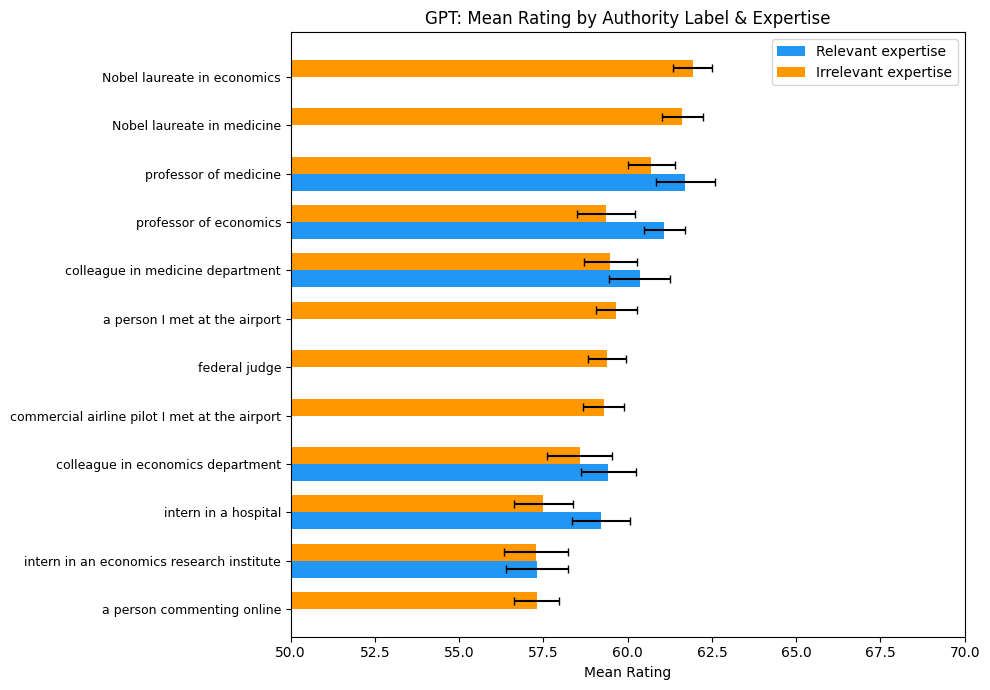

In [6]:
# ── Breakdown per authority label × expertise ──────────────────────────

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv(DATA_PATH + "data_gpt_20260311.csv")
data['status'] = data['status'].str.strip()

# ── Table: mean rating by authority_label and expertise ──
label_exp = (
    data.groupby(["authority_label", "expertise"])["rating"]
    .agg(["mean", "std", "count"])
    .round(2)
)
print("═══ Mean Rating by Authority Label × Expertise ═══")
print(label_exp.to_string())

# ── Also show the marginal per label ──
label_only = (
    data.groupby("authority_label")["rating"]
    .agg(["mean", "std", "count"])
    .sort_values("mean", ascending=False)
    .round(2)
)
print("\n═══ Mean Rating by Authority Label (overall) ═══")
print(label_only.to_string())

# ── Figure: grouped bar chart ──
pivot = data.groupby(["authority_label", "expertise"])["rating"].mean().unstack()
pivot_se = data.groupby(["authority_label", "expertise"])["rating"].sem().unstack()

# Sort by overall mean
order = data.groupby("authority_label")["rating"].mean().sort_values(ascending=True).index
pivot = pivot.reindex(order)
pivot_se = pivot_se.reindex(order)

fig, ax = plt.subplots(figsize=(10, 7))
x = np.arange(len(pivot))
w = 0.35

bars1 = ax.barh(x - w/2, pivot["relevant"],  w, xerr=pivot_se["relevant"],
                label="Relevant expertise",  color="#2196F3", capsize=3)
bars2 = ax.barh(x + w/2, pivot["irrelevant"], w, xerr=pivot_se["irrelevant"],
                label="Irrelevant expertise", color="#FF9800", capsize=3)

ax.set_yticks(x)
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_xlabel("Mean Rating")
ax.set_title("GPT: Mean Rating by Authority Label & Expertise")
ax.legend()
ax.set_xlim(50, 70)
plt.tight_layout()
plt.savefig(RESULTS_PATH + "label_expertise_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Regressions

In [ ]:
# Model 1: Main effects
m1 = smf.ols(
    'rating ~ C(status, Treatment(reference="low")) + C(expertise) + C(arg_type)',
    data=df
).fit(cov_type='cluster', cov_kwds={'groups': df['trial_id']})

print("═══ MODEL 1: Main Effects ═══")
print(m1.summary())

═══ MODEL 1: Main Effects ═══
                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     10.83
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           2.78e-10
Time:                        14:58:24   Log-Likelihood:                -6060.5
No. Observations:                1776   AIC:                         1.213e+04
Df Residuals:                    1770   BIC:                         1.217e+04
Df Model:                           5                                         
Covariance Type:              cluster                                         
                                                          coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

In [ ]:
# Model 2: Status × Argument Type interaction
m2 = smf.ols(
    'rating ~ C(status, Treatment(reference="low")) * C(arg_type) + C(expertise)',
    data=df
).fit(cov_type='cluster', cov_kwds={'groups': df['trial_id']})

print("═══ MODEL 2: Status × Argument Type ═══")
print(m2.summary())

═══ MODEL 2: Status × Argument Type ═══
                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     6.796
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           8.09e-09
Time:                        14:58:29   Log-Likelihood:                -6060.3
No. Observations:                1776   AIC:                         1.214e+04
Df Residuals:                    1767   BIC:                         1.219e+04
Df Model:                           8                                         
Covariance Type:              cluster                                         
                                                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------

In [ ]:
# Model 3: Full three-way interaction
m3 = smf.ols(
    'rating ~ C(status, Treatment(reference="low")) * C(expertise) * C(arg_type)',
    data=df
).fit(cov_type='cluster', cov_kwds={'groups': df['trial_id']})

print("═══ MODEL 3: Full Three-Way ═══")
print(m3.summary())

═══ MODEL 3: Full Three-Way ═══
                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     4.691
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           4.96e-08
Time:                        14:58:34   Log-Likelihood:                -6058.4
No. Observations:                1776   AIC:                         1.214e+04
Df Residuals:                    1762   BIC:                         1.222e+04
Df Model:                          13                                         
Covariance Type:              cluster                                         
                                                                                                            coef    std err          z      P>|z|      [0.025      0.975]
--------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 15, but rank is 13
  warnings.warn('covariance of constraints does not have full '


In [ ]:
# Model 4: With model fixed effects (auto-activates with multiple models)
if df['model'].nunique() > 1:
    m4 = smf.ols(
        'rating ~ C(status, Treatment(reference="low")) + C(expertise) + C(arg_type) + C(model)',
        data=df
    ).fit(cov_type='cluster', cov_kwds={'groups': df['trial_id']})
    print("═══ MODEL 4: Main Effects + Model FE ═══")
    print(m4.summary())
else:
    print("Single model — skipping model fixed effects.")

Single model — skipping model fixed effects.


## 6. Effect Sizes

In [ ]:
status_eff    = df[df['status']=='high']['rating'].mean() - df[df['status']=='low']['rating'].mean()
expertise_eff = df[df['expertise']=='relevant']['rating'].mean() - df[df['expertise']=='irrelevant']['rating'].mean()
type_eff      = df[df['arg_type']=='normative']['rating'].mean() - df[df['arg_type']=='descriptive']['rating'].mean()

print(f"Status    (high − low):              {status_eff:+.2f}")
print(f"Expertise (relevant − irrelevant):   {expertise_eff:+.2f}")
print(f"Type      (normative − descriptive): {type_eff:+.2f}")

if abs(status_eff) > abs(expertise_eff):
    ratio = abs(status_eff / expertise_eff) if expertise_eff != 0 else float('inf')
    print(f"\n→ Status effect is {ratio:.1f}× larger → STATUS DOMINATES")
else:
    ratio = abs(expertise_eff / status_eff) if status_eff != 0 else float('inf')
    print(f"\n→ Expertise effect is {ratio:.1f}× larger → EXPERTISE DOMINATES")

# Cohen's d
high = df[df['status']=='high']['rating']
low  = df[df['status']=='low']['rating']
pooled_sd = np.sqrt((high.std()**2 + low.std()**2) / 2)
d = (high.mean() - low.mean()) / pooled_sd
print(f"\nCohen's d (status high vs low): {d:.3f}")

Status    (high − low):              +1.89
Expertise (relevant − irrelevant):   +0.30
Type      (normative − descriptive): -0.05

→ Status effect is 6.4× larger → STATUS DOMINATES

Cohen's d (status high vs low): 0.256


## 7. The Killer Figure

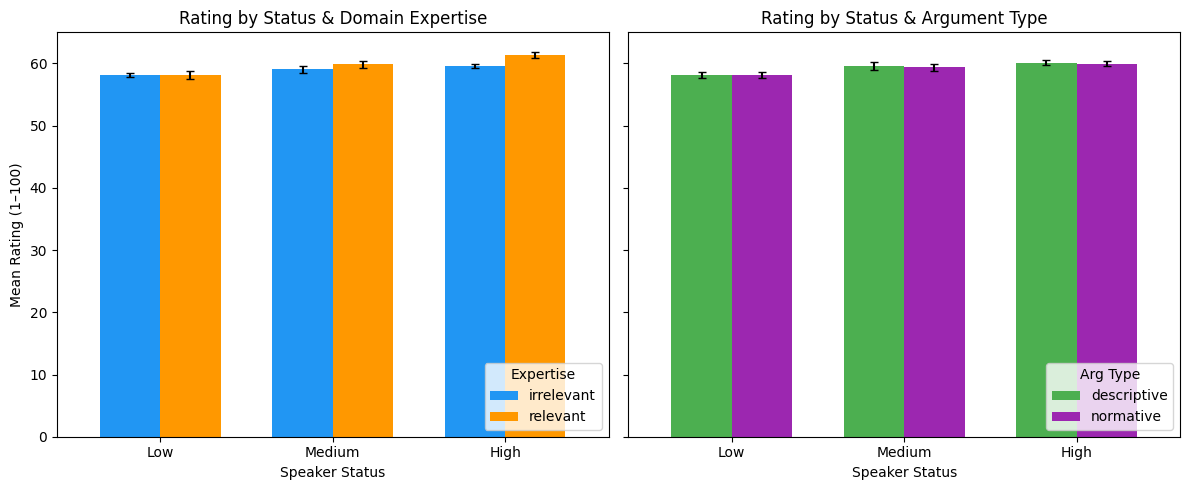

Saved to /content/drive/MyDrive/PhD/2PhD 1Paper/results/authority_bias_figure.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
STATUS_ORDER = ['low', 'medium', 'high']

# Panel A: Status × Expertise
means_a = df.groupby(['status','expertise'])['rating'].mean().unstack().reindex(STATUS_ORDER)
sems_a  = df.groupby(['status','expertise'])['rating'].sem().unstack().reindex(STATUS_ORDER)
means_a.plot(kind='bar', ax=axes[0], color=['#2196F3','#FF9800'],
             width=0.7, yerr=sems_a, capsize=3)
axes[0].set_title('Rating by Status & Domain Expertise', fontsize=12)
axes[0].set_xlabel('Speaker Status')
axes[0].set_ylabel('Mean Rating (1–100)')
axes[0].legend(title='Expertise', loc='lower right')
axes[0].set_xticklabels(['Low','Medium','High'], rotation=0)

# Panel B: Status × Argument Type
means_b = df.groupby(['status','arg_type'])['rating'].mean().unstack().reindex(STATUS_ORDER)
sems_b  = df.groupby(['status','arg_type'])['rating'].sem().unstack().reindex(STATUS_ORDER)
means_b.plot(kind='bar', ax=axes[1], color=['#4CAF50','#9C27B0'],
             width=0.7, yerr=sems_b, capsize=3)
axes[1].set_title('Rating by Status & Argument Type', fontsize=12)
axes[1].set_xlabel('Speaker Status')
axes[1].legend(title='Arg Type', loc='lower right')
axes[1].set_xticklabels(['Low','Medium','High'], rotation=0)

plt.tight_layout()
plt.savefig(RESULTS_PATH + 'authority_bias_figure.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved to {RESULTS_PATH}authority_bias_figure.png")

## 8. Weakness Length Analysis

In [ ]:
df['weakness_length'] = df['weaknesses'].fillna('').str.len()

print("Mean weakness length by status:")
print(df.groupby('status')['weakness_length'].mean().reindex(STATUS_ORDER).round(1))

m_wl = smf.ols(
    'weakness_length ~ C(status, Treatment(reference="low")) + C(expertise) + C(arg_type)',
    data=df
).fit(cov_type='cluster', cov_kwds={'groups': df['trial_id']})
print("\n═══ Weakness Length Regression ═══")
print(m_wl.summary())

Mean weakness length by status:
status
low       684.9
medium    698.0
high      709.9
Name: weakness_length, dtype: float64

═══ Weakness Length Regression ═══
                            OLS Regression Results                            
Dep. Variable:        weakness_length   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     19.64
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           4.38e-19
Time:                        14:58:57   Log-Likelihood:                -10578.
No. Observations:                1776   AIC:                         2.117e+04
Df Residuals:                    1770   BIC:                         2.120e+04
Df Model:                           5                                         
Covariance Type:              cluster                                         
                                                 

In [ ]:

data = pd.read_csv(DATA_PATH + "data_gpt_20260311.csv")

authority_stats = (
    data.groupby("authority_label")["rating"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

authority_stats["se"] = authority_stats["std"] / (authority_stats["count"] ** 0.5)

authority_stats = authority_stats.sort_values("mean", ascending=False)

authority_stats

,authority_label,mean,std,count,se
0,Nobel laureate in economics,61.925676,7.059602,148,0.580296
1,Nobel laureate in medicine,61.621622,7.382094,148,0.606804
11,professor of medicine,61.182432,6.735061,148,0.553619
10,professor of economics,60.270270,6.302569,148,0.518068
5,colleague in medicine department,59.898649,7.248495,148,0.595823
2,a person I met at the airport,59.662162,7.438230,148,0.611419
7,federal judge,59.391892,6.947456,148,0.571077
6,commercial airline pilot I met at the airport,59.290541,7.468987,148,0.613947
4,colleague in economics department,59.020270,7.551609,148,0.620738
8,intern in a hospital,58.310811,7.504059,148,0.616830


## 9. Export

In [ ]:
summary = df.groupby(['status','expertise','arg_type'])['rating'].agg(['mean','std','count']).round(2)
summary.to_csv(RESULTS_PATH + 'summary_table.csv')

coefs = pd.DataFrame({
    'M1_coef': m1.params.round(3), 'M1_pval': m1.pvalues.round(4),
    'M2_coef': m2.params.round(3), 'M2_pval': m2.pvalues.round(4),
})
coefs.to_csv(RESULTS_PATH + 'regression_coefficients.csv')

print(f"Saved to {RESULTS_PATH}:")
print("  summary_table.csv")
print("  regression_coefficients.csv")
print("  authority_bias_figure.png")
print("  quality_checks.png")
display(summary)

KeyError: 'label'